# 01 — Data Pipeline

Questo notebook costruisce il dataset di coppie `(clean_mel, degraded_mel)` utilizzato per addestrare la U-Net di restauro audio.

**Flusso generale:**
1. Scarica FMA-small (dataset audio libero, 8000 tracce ~30s)
2. Carica EnCodec 24 kHz per degradare l'audio (simula gli artefatti RVQ che MusicGen produce)
3. Per ogni traccia: estrai segmento → encode→decode con EnCodec → calcola Mel spectrogrammi clean e degraded
4. Salva le coppie su Google Drive come tensori `.pt`
5. Verifica integrità e visualizza campioni

## Cella 0 — Configurazione

Unico punto di verità per tutti gli iperparametri della pipeline.
Modificare qui prima di ri-eseguire qualunque altra cella.

In [1]:
# ── Percorsi ──────────────────────────────────────────────────────────────────
DRIVE_ROOT        = "/content/drive/MyDrive/audio-restoration"
DATA_DIR          = f"{DRIVE_ROOT}/data/train"
FMA_LOCAL         = "/content/fma_small"

# ── Audio ─────────────────────────────────────────────────────────────────────
TARGET_SR         = 24_000          # sample rate EnCodec 24 kHz
SEGMENT_SAMPLES   = 96_000          # 4 s @ 24 kHz

# ── Mel spectrogram ───────────────────────────────────────────────────────────
N_MELS            = 128
N_FFT             = 1024
HOP_LENGTH        = 256
F_MIN             = 0
F_MAX             = 12_000

# ── Dataset ───────────────────────────────────────────────────────────────────
TARGET_PAIRS      = 2000

# ── EnCodec ───────────────────────────────────────────────────────────────────
BANDWIDTH         = 6.0             # kbps — corrisponde a 8 codebook RVQ

print("Configurazione caricata.")
print(f"  TARGET_SR={TARGET_SR}  SEGMENT={SEGMENT_SAMPLES/TARGET_SR:.1f}s  N_MELS={N_MELS}")
print(f"  TARGET_PAIRS={TARGET_PAIRS}  BANDWIDTH={BANDWIDTH} kbps")

Configurazione caricata.
  TARGET_SR=24000  SEGMENT=4.0s  N_MELS=128
  TARGET_PAIRS=2000  BANDWIDTH=6.0 kbps


## Cella 1 — Installazione dipendenze

- `encodec`: modello Meta per compressione/degradazione audio neurale
- `torchaudio`: I/O audio e trasformazioni (MelSpectrogram)
- `tqdm`: progress bar per il loop principale
- `huggingface_hub`: fallback per scaricare FMA se il server ufficiale non risponde

In [2]:
import subprocess, sys

def pip_install(*packages):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

pip_install("encodec", "torchaudio", "tqdm", "huggingface_hub")
print("Dipendenze installate.")

Dipendenze installate.


## Cella 2 — Mount Google Drive e creazione cartelle

I file `.pt` delle coppie vengono salvati su Drive per persistere tra le sessioni Colab.
`DATA_DIR` viene creata se non esiste già (idempotente).

In [3]:
import os
from google.colab import drive

DRIVE_ROOT      = "/content/drive/MyDrive/audio-restoration"
DATA_DIR        = f"{DRIVE_ROOT}/data/train"

drive.mount("/content/drive", force_remount=False)

os.makedirs(DATA_DIR, exist_ok=True)
print(f"Drive montato. Cartella output: {DATA_DIR}")
print(f"File già presenti: {len([f for f in os.listdir(DATA_DIR) if f.endswith('.pt')])}")

Mounted at /content/drive
Drive montato. Cartella output: /content/drive/MyDrive/audio-restoration/data/train
File già presenti: 0


## Cella 3 — Download FMA-small

FMA-small contiene 8000 tracce MP3 a 128 kbps (~30s) suddivise in 8 generi.

**Strategia:**
1. Tentativo primario: `wget` dal server ufficiale `os.unil.ch` (~7.2 GB)
2. Fallback: `huggingface_hub.snapshot_download` da un mirror HuggingFace

Il file zip viene decompresso in `FMA_LOCAL`; se la cartella esiste già il download viene saltato.

In [4]:
# Cella 3 — Download FMA-small via Kaggle API
# Usiamo Colab Secrets per la key (sicuro, non esposta nel codice)

from google.colab import userdata
import os
import subprocess

# Leggi token da Colab Secrets
os.environ['KAGGLE_TOKEN'] = userdata.get('KAGGLE_TOKEN')

# Installa kaggle
!pip install -q kaggle

# Scarica FMA-small
!kaggle datasets download \
  -d imsparsh/fma-free-music-archive-small-medium \
  -p /content/

# Decomprimi
!unzip -q /content/fma-free-music-archive-small-medium.zip \
  -d /content/fma_small/

# Conta MP3
import glob
mp3_files = glob.glob('/content/fma_small/**/*.mp3', recursive=True)
n_mp3 = len(mp3_files)
print(f"\nMP3 trovati: {n_mp3}")
assert n_mp3 > 0, "Nessun MP3 trovato — verifica il download"

Dataset URL: https://www.kaggle.com/datasets/imsparsh/fma-free-music-archive-small-medium
License(s): CC0-1.0
100% 29.8G/29.8G [05:29<00:00, 97.1MB/s]


MP3 trovati: 23987


## Cella 4 — Caricamento modello EnCodec

EnCodec 24 kHz è il codec neurale di Meta usato internamente da MusicGen.
Con `bandwidth=6.0` kbps vengono attivati 8 codebook RVQ → il segnale decodificato
presenta gli stessi artefatti che vediamo nell'audio generato da MusicGen.

Il modello viene messo in `eval()` e i gradienti disabilitati: serve solo per l'inferenza.

In [5]:
import torch
from encodec import EncodecModel

BANDWIDTH = 6.0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encodec_model = EncodecModel.encodec_model_24khz()
encodec_model.set_target_bandwidth(BANDWIDTH)
encodec_model = encodec_model.to(device).eval()

for param in encodec_model.parameters():
    param.requires_grad_(False)

print(f"EnCodec caricato su: {device}")
print(f"Bandwidth impostata: {BANDWIDTH} kbps")
if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}  ({props.total_memory // 1024**2} MB VRAM)")

/usr/local/lib/python3.12/dist-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Downloading: "https://dl.fbaipublicfiles.com/encodec/v0/encodec_24khz-d7cc33bc.th" to /root/.cache/torch/hub/checkpoints/encodec_24khz-d7cc33bc.th


100%|██████████| 88.9M/88.9M [00:00<00:00, 152MB/s]


EnCodec caricato su: cuda
Bandwidth impostata: 6.0 kbps
GPU: Tesla T4  (14912 MB VRAM)


## Cella 5 — Pipeline di degradazione

La funzione `process_track` implementa l'intera catena di trasformazione per una singola traccia:

```
MP3 → mono → resample 24kHz → segmento 4s → EnCodec encode→decode → log-MelSpec
                                                                    ↗ clean_mel
                                                                    ↘ degraded_mel
```

Il log-mel con clamping `log(clamp(mel, 1e-5))` è la rappresentazione standard
usata da vocoder neurali (Vocos, HiFi-GAN) e garantisce valori stabili in `[-11.5, ~8]`.

In [6]:
import torch
import torchaudio
import torchaudio.transforms as T
from typing import Optional, Dict

# ── Re-import configurazione (cella standalone) ───────────────────────────────
TARGET_SR       = 24_000
SEGMENT_SAMPLES = 96_000
N_MELS          = 128
N_FFT           = 1024
HOP_LENGTH      = 256
F_MIN           = 0
F_MAX           = 12_000


def _build_mel_transform(sr: int, device: torch.device) -> T.MelSpectrogram:
    """Costruisce il trasformatore MelSpectrogram con i parametri del progetto."""
    return T.MelSpectrogram(
        sample_rate=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        f_min=F_MIN,
        f_max=F_MAX,
        power=1.0,          # ampiezza (non potenza) → più stabile con log
        center=True,
        pad_mode="reflect",
        norm="slaney",
        mel_scale="slaney",
    ).to(device)


def _log_mel(mel: torch.Tensor) -> torch.Tensor:
    return torch.log(torch.clamp(mel, min=1e-5))


def process_track(
    mp3_path: str,
    model: "EncodecModel",
    device: torch.device,
) -> Optional[Dict[str, torch.Tensor]]:
    """
    Processa una singola traccia MP3 e restituisce la coppia di log-mel spectrogrammi.

    Returns:
        dict con chiavi 'clean_mel' e 'degraded_mel' (tensori CPU, shape [1, N_MELS, T])
        oppure None se la traccia non è utilizzabile.
    """
    try:
        # 1. Carica audio
        waveform, sr = torchaudio.load(mp3_path)

        # 2. Converti in mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # 3. Resample a TARGET_SR
        if sr != TARGET_SR:
            resampler = T.Resample(orig_freq=sr, new_freq=TARGET_SR).to(waveform.device)
            waveform = resampler(waveform)

        # 4. Estrai segmento di SEGMENT_SAMPLES campioni
        n_samples = waveform.shape[-1]
        if n_samples < SEGMENT_SAMPLES:
            return None   # traccia troppo corta
        if n_samples == SEGMENT_SAMPLES:
            start = 0
        else:
            start = torch.randint(0, n_samples - SEGMENT_SAMPLES, (1,)).item()
        waveform = waveform[:, start : start + SEGMENT_SAMPLES]  # [1, S]

        # 5. EnCodec encode → decode
        # EnCodec si aspetta [B, C, T] con valori in [-1, 1]
        wav_enc = waveform.unsqueeze(0).to(device)              # [1, 1, S]
        with torch.no_grad():
            encoded_frames = model.encode(wav_enc)
            degraded_wav   = model.decode(encoded_frames)       # [1, 1, S']

        # Riporta a CPU e rimuovi batch dim
        clean_wav    = waveform.to(device)                      # [1, S]
        degraded_wav = degraded_wav.squeeze(0)                  # [1, S']

        # Uniforma lunghezza (il decoder può produrre qualche campione in più/meno)
        min_len = min(clean_wav.shape[-1], degraded_wav.shape[-1])
        clean_wav    = clean_wav[..., :min_len]
        degraded_wav = degraded_wav[..., :min_len]

        # 6. Log-MelSpectrogram
        mel_transform = _build_mel_transform(TARGET_SR, device)
        clean_mel    = _log_mel(mel_transform(clean_wav))       # [1, N_MELS, T]
        degraded_mel = _log_mel(mel_transform(degraded_wav))    # [1, N_MELS, T]

        return {
            "clean_mel":    clean_mel.cpu(),
            "degraded_mel": degraded_mel.cpu(),
        }

    except Exception:
        # File corrotto, troppo corto, errore di decodifica MP3 — skippa silenziosamente
        return None


print("Funzione process_track definita.")
print(f"  Segmento: {SEGMENT_SAMPLES/TARGET_SR:.1f}s  |  Mel: {N_MELS} bande  |  FFT: {N_FFT}  |  Hop: {HOP_LENGTH}")

Funzione process_track definita.
  Segmento: 4.0s  |  Mel: 128 bande  |  FFT: 1024  |  Hop: 256


## Cella 6 — Loop principale: costruzione dataset

Scansiona tutti gli MP3 di FMA-small, li mischia (per varietà di generi) e chiama
`process_track` su ognuno fino a raggiungere `TARGET_PAIRS` coppie valide.

Ogni coppia viene salvata come dizionario PyTorch `pair_XXXX.pt` in `DATA_DIR`.
I checkpoint ogni 100 coppie aiutano a monitorare la velocità della pipeline
e a stimare il tempo rimanente.

In [7]:
import os
import glob
import time
import random
import torch
from tqdm.auto import tqdm

# ── Re-import configurazione ──────────────────────────────────────────────────
DRIVE_ROOT      = "/content/drive/MyDrive/audio-restoration"
DATA_DIR        = f"{DRIVE_ROOT}/data/train"
FMA_LOCAL       = "/content/fma_small"
TARGET_PAIRS    = 2000

# ── Recupera device e modello già caricati ────────────────────────────────────
# (encodec_model e device sono definiti nella Cella 4)
# Se questa cella viene eseguita in isolamento, ricaricare la Cella 4 prima.

os.makedirs(DATA_DIR, exist_ok=True)

# ── Conta coppie già salvate (resume automatico) ──────────────────────────────
existing = sorted(glob.glob(os.path.join(DATA_DIR, "pair_*.pt")))
already_done = len(existing)
print(f"Coppie già presenti su Drive: {already_done} / {TARGET_PAIRS}")

if already_done >= TARGET_PAIRS:
    print("Dataset già completo. Nessuna elaborazione necessaria.")
else:
    # ── Scansione MP3 ─────────────────────────────────────────────────────────
    all_mp3s = glob.glob(os.path.join(FMA_LOCAL, "**", "*.mp3"), recursive=True)
    random.seed(42)
    random.shuffle(all_mp3s)
    print(f"MP3 disponibili: {len(all_mp3s)}")

    # ── Loop ──────────────────────────────────────────────────────────────────
    saved       = already_done
    skipped     = 0
    t_start     = time.time()
    checkpoint  = 100

    pbar = tqdm(total=TARGET_PAIRS - already_done, desc="Coppie salvate", unit="pair")

    for mp3_path in all_mp3s:
        if saved >= TARGET_PAIRS:
            break

        try:
            result = process_track(mp3_path, encodec_model, device)
        except Exception:
            result = None

        if result is None:
            skipped += 1
            continue

        save_path = os.path.join(DATA_DIR, f"pair_{saved:04d}.pt")
        torch.save(result, save_path)
        saved += 1
        pbar.update(1)

        # Checkpoint ogni 100 coppie
        if saved % checkpoint == 0:
            elapsed   = time.time() - t_start
            rate      = (saved - already_done) / elapsed
            remaining = (TARGET_PAIRS - saved) / rate if rate > 0 else float("inf")
            tqdm.write(
                f"[checkpoint] saved={saved:4d}  skipped={skipped:4d}  "
                f"elapsed={elapsed/60:.1f}min  ~remaining={remaining/60:.1f}min"
            )

    pbar.close()

    total_elapsed = time.time() - t_start
    print(f"\nLoop completato.")
    print(f"  Coppie salvate in questa sessione : {saved - already_done}")
    print(f"  Totale nel dataset               : {saved}")
    print(f"  File skippati                    : {skipped}")
    print(f"  Tempo totale                     : {total_elapsed/60:.1f} min")

Coppie già presenti su Drive: 0 / 2000
MP3 disponibili: 23987


Coppie salvate:   0%|          | 0/2000 [00:00<?, ?pair/s]

[checkpoint] saved= 100  skipped=   0  elapsed=0.4min  ~remaining=6.8min
[checkpoint] saved= 200  skipped=   0  elapsed=0.6min  ~remaining=5.3min
[checkpoint] saved= 300  skipped=   0  elapsed=0.8min  ~remaining=4.6min
[checkpoint] saved= 400  skipped=   0  elapsed=1.0min  ~remaining=4.1min
[checkpoint] saved= 500  skipped=   0  elapsed=1.3min  ~remaining=3.8min
[checkpoint] saved= 600  skipped=   0  elapsed=1.5min  ~remaining=3.5min
[checkpoint] saved= 700  skipped=   0  elapsed=1.7min  ~remaining=3.2min
[checkpoint] saved= 800  skipped=   0  elapsed=1.9min  ~remaining=2.9min
[checkpoint] saved= 900  skipped=   0  elapsed=2.2min  ~remaining=2.7min
[checkpoint] saved=1000  skipped=   0  elapsed=2.4min  ~remaining=2.4min
[checkpoint] saved=1100  skipped=   0  elapsed=2.6min  ~remaining=2.1min
[checkpoint] saved=1200  skipped=   0  elapsed=2.8min  ~remaining=1.9min
[checkpoint] saved=1300  skipped=   0  elapsed=3.1min  ~remaining=1.6min
[checkpoint] saved=1400  skipped=   0  elapsed=3.3m

## Cella 7 — Verifica dataset

Controlla che le coppie salvate abbiano la forma attesa e misura la qualità della degradazione
tramite **Log Spectral Distance (LSD)**:

$$\text{LSD} = \frac{1}{K} \sum_{k} \sqrt{\frac{1}{T} \sum_{t} \left( \log S_{\text{clean}}(k,t) - \log S_{\text{deg}}(k,t) \right)^2}$$

Un LSD > 0 conferma che EnCodec ha effettivamente introdotto artefatti udibili.
Valori tipici attesi: 0.3–1.5 dB a seconda del genere musicale.

Coppie totali nel dataset: 2000

──────────────────────────────────────────────────────────────────────
Campo           Shape                       Min      Max     Mean
──────────────────────────────────────────────────────────────────────
pair_160 clean_mel (1, 128, 376)           -11.513    1.556   -5.533
pair_160 degraded_mel (1, 128, 376)           -11.297    1.601   -5.342
  → LSD: 0.7884

pair_072 clean_mel (1, 128, 376)            -7.267    1.229   -4.044
pair_072 degraded_mel (1, 128, 376)            -8.871    1.281   -4.084
  → LSD: 0.5065

pair_046 clean_mel (1, 128, 376)           -11.513    0.929   -5.348
pair_046 degraded_mel (1, 128, 376)           -11.513    0.892   -5.174
  → LSD: 0.7934

──────────────────────────────────────────────────────────────────────
LSD medio sulle 3 coppie: 0.6961
(Atteso: 0.3–1.5 per audio degradato da EnCodec 6 kbps)


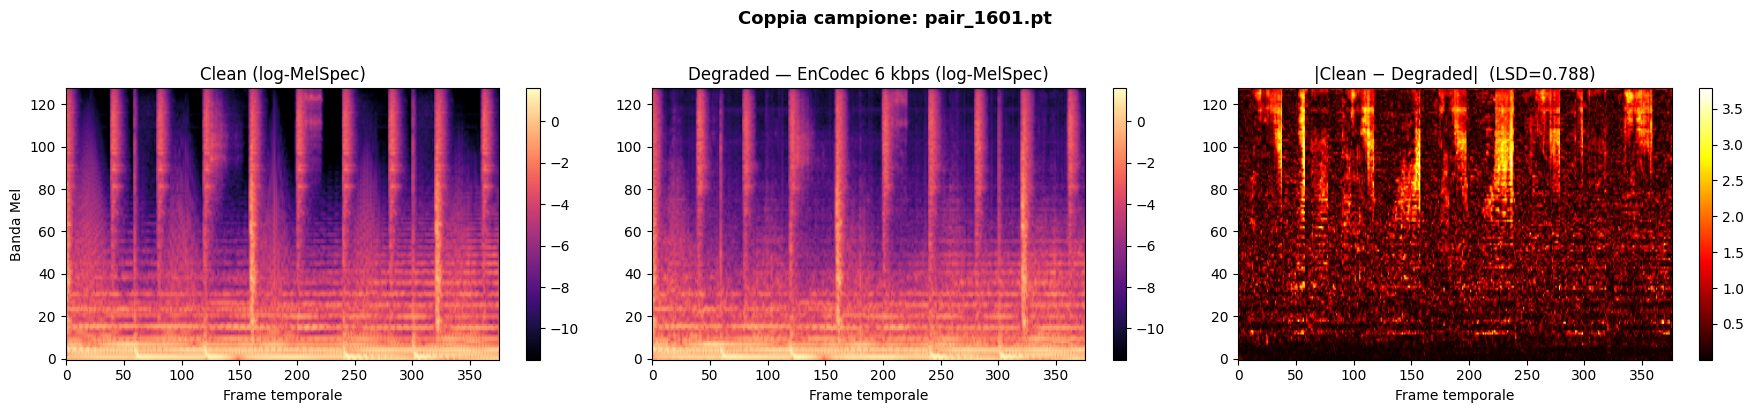

Figura salvata in /content/sample_pair.png


In [8]:
import os
import glob
import random
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

DRIVE_ROOT = "/content/drive/MyDrive/audio-restoration"
DATA_DIR   = f"{DRIVE_ROOT}/data/train"
N_VERIFY   = 3

# ── Carica coppie casuali ─────────────────────────────────────────────────────
all_pairs = sorted(glob.glob(os.path.join(DATA_DIR, "pair_*.pt")))
assert len(all_pairs) > 0, f"Nessun file .pt trovato in {DATA_DIR}"
print(f"Coppie totali nel dataset: {len(all_pairs)}")

sample_paths = random.sample(all_pairs, min(N_VERIFY, len(all_pairs)))
samples      = [torch.load(p, weights_only=True) for p in sample_paths]


def log_spectral_distance(clean: torch.Tensor, degraded: torch.Tensor) -> float:
    """
    LSD medio su tutti i frame temporali.
    Input: log-mel spectrogrammi [1, N_MELS, T]
    """
    diff_sq = (clean - degraded) ** 2          # [1, N_MELS, T]
    lsd_per_band = diff_sq.mean(dim=-1).sqrt() # [1, N_MELS]
    return lsd_per_band.mean().item()


# ── Statistiche per campione ──────────────────────────────────────────────────
lsd_values = []
print(f"\n{'─'*70}")
print(f"{'Campo':<15} {'Shape':<22} {'Min':>8} {'Max':>8} {'Mean':>8}")
print(f"{'─'*70}")

for i, (path, sample) in enumerate(zip(sample_paths, samples)):
    fname = os.path.basename(path)
    for key in ("clean_mel", "degraded_mel"):
        t = sample[key]
        print(f"{fname[:8]+' '+key:<15} {str(tuple(t.shape)):<22} "
              f"{t.min().item():>8.3f} {t.max().item():>8.3f} {t.mean().item():>8.3f}")
    lsd = log_spectral_distance(sample["clean_mel"], sample["degraded_mel"])
    lsd_values.append(lsd)
    print(f"  → LSD: {lsd:.4f}")
    print()

print(f"{'─'*70}")
print(f"LSD medio sulle {N_VERIFY} coppie: {np.mean(lsd_values):.4f}")
print(f"(Atteso: 0.3–1.5 per audio degradato da EnCodec 6 kbps)")

# ── Visualizzazione comparativa ───────────────────────────────────────────────
sample_to_plot = samples[0]
clean_np    = sample_to_plot["clean_mel"].squeeze(0).numpy()     # [N_MELS, T]
degraded_np = sample_to_plot["degraded_mel"].squeeze(0).numpy()
diff_np     = np.abs(clean_np - degraded_np)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
vmin = min(clean_np.min(), degraded_np.min())
vmax = max(clean_np.max(), degraded_np.max())

im0 = axes[0].imshow(clean_np,    aspect="auto", origin="lower",
                     vmin=vmin, vmax=vmax, cmap="magma")
axes[0].set_title("Clean (log-MelSpec)", fontsize=12)
axes[0].set_xlabel("Frame temporale")
axes[0].set_ylabel("Banda Mel")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(degraded_np, aspect="auto", origin="lower",
                     vmin=vmin, vmax=vmax, cmap="magma")
axes[1].set_title("Degraded — EnCodec 6 kbps (log-MelSpec)", fontsize=12)
axes[1].set_xlabel("Frame temporale")
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(diff_np,     aspect="auto", origin="lower",
                     cmap="hot")
axes[2].set_title(f"|Clean − Degraded|  (LSD={lsd_values[0]:.3f})", fontsize=12)
axes[2].set_xlabel("Frame temporale")
plt.colorbar(im2, ax=axes[2])

plt.suptitle(
    f"Coppia campione: {os.path.basename(sample_paths[0])}",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig("/content/sample_pair.png", dpi=120, bbox_inches="tight")
plt.show()
print("Figura salvata in /content/sample_pair.png")